# Session 2 — Normal Return Models

**Course: Event Studies in Finance & Economics**

*Mathis Mourey*

---

The quality of an event study depends almost entirely on the quality of the counterfactual: what would the return have been, had the event not occurred? This counterfactual is the **normal return model**, and its choice is the single most consequential design decision a researcher makes.

In this session, we focus on the normal return models used in practice, from the simplest (constant mean) to the most elaborate (Fama-French five-factor). For each model, we present the specification, the estimation procedure, and the properties of the resulting abnormal returns. We then compare all models on the same dataset, showing when model choice matters and when it does not. Finally, we introduce formal diagnostic tools for assessing parameter stability and residual behavior.

The core trade-off throughout is **model sophistication versus estimation noise**: a richer model removes more systematic return variation, but introduces more parameters that must be estimated, each with its own sampling error.

**References for this session:**

- Brown, S.J. and Warner, J.B. (1980). Measuring Security Price Performance. *Journal of Financial Economics*, 8(3), 205--258.
- Brown, S.J. and Warner, J.B. (1985). Using Daily Stock Returns. *Journal of Financial Economics*, 14(1), 3--31.
- Campbell, J.Y., Lo, A.W. and MacKinlay, A.C. (1997). *The Econometrics of Financial Markets*. Princeton University Press, Chapter 4.
- Carhart, M.M. (1997). On Persistence in Mutual Fund Performance. *Journal of Finance*, 52(1), 57--82.
- Fama, E.F. and French, K.R. (1993). Common Risk Factors in the Returns on Stocks and Bonds. *Journal of Financial Economics*, 33(1), 3--56.
- Fama, E.F. and French, K.R. (2015). A Five-Factor Asset Pricing Model. *Journal of Financial Economics*, 116(1), 1--22.
- MacKinlay, A.C. (1997). Event Studies in Economics and Finance. *Journal of Economic Literature*, 35(1), 13--39.
- Patell, J.M. (1976). Corporate Forecasts of Earnings Per Share and Stock Price Behavior: Empirical Tests. *Journal of Accounting Research*, 14(2), 246--276.
- Scholes, M. and Williams, J. (1977). Estimating Betas from Nonsynchronous Data. *Journal of Financial Economics*, 5(3), 309--327.
- Dimson, E. (1979). Risk Measurement When Shares Are Subject to Infrequent Trading. *Journal of Financial Economics*, 7(2), 197--226.

## A Taxonomy of Normal Return Models

Normal return models can be arranged along a spectrum of increasing complexity. At one end, the constant mean return model assumes that the expected return of a security is simply its historical average. At the other end, multi-factor models attempt to capture all systematic sources of return variation.

The key insight from Brown and Warner (1980, 1985) is that, for **short-horizon** event studies with well-defined event dates, the simple models often perform nearly as well as the complex ones. The reason is that the event window is short (say, 3 days), so the variance reduction from a better model is small relative to the noise in the abnormal return. For **long-horizon** studies, or when events cluster in calendar time, model choice matters considerably more.

We now present each model in turn, building from simple to complex. For concreteness, let $R_{i,t}$ denote the return on security $i$ on day $t$, and let the estimation window run from $t = 1$ to $t = L$.

## 1. The Constant Mean Return Model

The simplest benchmark assumes that the expected return is constant over time:

$$
R_{i,t} = \mu_i + \varepsilon_{i,t}, \qquad \varepsilon_{i,t} \sim (0, \sigma^2_{\varepsilon_i})
$$

The estimator is the sample mean over the estimation window:

$$
\hat{\mu}_i = \frac{1}{L} \sum_{t=1}^{L} R_{i,t}
$$

The abnormal return is:

$$
AR_{i,\tau} = R_{i,\tau} - \hat{\mu}_i
$$

Under the null of no event effect, the variance of the abnormal return is:

$$
\text{Var}(AR_{i,\tau}) = \sigma^2_{\varepsilon_i}\left(1 + \frac{1}{L}\right)
$$

The $1/L$ term reflects estimation error in $\hat{\mu}_i$ and vanishes as $L \to \infty$.

This model has one virtue: it does not require any data beyond the firm's own return history. It has one major weakness: it does not remove market-wide return variation. On a day when the entire market falls 3%, the constant mean model would attribute most of that decline to the firm-specific abnormal return. For this reason, the constant mean model works best when market returns are close to zero on average over the event window, which is approximately true for very short windows.

## 2. The Market-Adjusted Return Model

The market-adjusted model removes the contemporaneous market return, but does not estimate any parameters:

$$
AR_{i,\tau} = R_{i,\tau} - R_{m,\tau}
$$

This is equivalent to the market model with $\alpha_i = 0$ and $\beta_i = 1$ imposed (rather than estimated). No estimation window is needed, which is useful when pre-event data is scarce (e.g., IPOs).

The model is exact for a firm with $\beta_i = 1$. For firms with $\beta_i \neq 1$, it introduces a bias proportional to $(\beta_i - 1) R_{m,\tau}$. On days when the market return is large, this bias can be substantial for high-beta or low-beta stocks.

Despite its simplicity, Brown and Warner (1985) found that the market-adjusted model performs comparably to the market model in simulations with random event dates. The intuition is that, across a large cross-section of firms, the average beta is close to one, so the biases cancel in the aggregate CAAR.

## 3. The Market Model

The market model is the workhorse of event studies. It posits a linear relation between the firm's return and the market return:

$$
R_{i,t} = \alpha_i + \beta_i R_{m,t} + \varepsilon_{i,t}, \qquad \varepsilon_{i,t} \sim \mathcal{N}(0, \sigma^2_{\varepsilon_i})
$$

The parameters are estimated by OLS over the estimation window. The abnormal return is:

$$
AR_{i,\tau} = R_{i,\tau} - \hat{\alpha}_i - \hat{\beta}_i R_{m,\tau}
$$

The conditional variance of $AR_{i,\tau}$ under the null, accounting for estimation error, is (MacKinlay, 1997, eq. 8):

$$
\text{Var}(AR_{i,\tau}) = \sigma^2_{\varepsilon_i}\left[1 + \frac{1}{L} + \frac{(R_{m,\tau} - \hat{\mu}_m)^2}{\sum_{t=1}^{L}(R_{m,t} - \hat{\mu}_m)^2}\right]
$$

where $\hat{\mu}_m = L^{-1}\sum_{t=1}^{L} R_{m,t}$. The third term captures the additional uncertainty when the event-window market return is far from its estimation-window mean. In practice, this correction is small for $L \geq 100$ and is often ignored.

The market model removes the component of the firm's return driven by market-wide movements. Since market movements are the dominant source of return variation for most stocks, this substantially reduces the variance of the abnormal return, increasing the power of event study tests.

The model assumes that $\alpha_i$ and $\beta_i$ are constant over both the estimation and event windows. If the event itself changes the firm's systematic risk (e.g., a leverage-increasing acquisition), the pre-event estimates may not apply in the event window. This is one motivation for multi-factor models and for diagnostic tests of parameter stability.

## 4. Multi-Factor Models

The market model captures only one source of systematic risk. Multi-factor models extend the specification to include additional factors that explain cross-sectional return variation. The general form is:

$$
R_{i,t} = \alpha_i + \sum_{k=1}^{K} \beta_{i,k} F_{k,t} + \varepsilon_{i,t}
$$

where $F_{k,t}$ is the return on factor $k$ at time $t$. The abnormal return is:

$$
AR_{i,\tau} = R_{i,\tau} - \hat{\alpha}_i - \sum_{k=1}^{K} \hat{\beta}_{i,k} F_{k,\tau}
$$

### 4.1 Fama-French Three-Factor Model

Fama and French (1993) proposed three factors: the market excess return ($R_m - R_f$), a size factor (SMB, "small minus big"), and a value factor (HML, "high minus low" book-to-market):

$$
R_{i,t} - R_{f,t} = \alpha_i + \beta_{i,\text{MKT}}(R_{m,t} - R_{f,t}) + \beta_{i,\text{SMB}} \cdot SMB_t + \beta_{i,\text{HML}} \cdot HML_t + \varepsilon_{i,t}
$$

The model is estimated on **excess returns** (firm return minus risk-free rate). The abnormal return for an event-window day is then:

$$
AR_{i,\tau} = (R_{i,\tau} - R_{f,\tau}) - \hat{\alpha}_i - \hat{\beta}_{i,\text{MKT}}(R_{m,\tau} - R_{f,\tau}) - \hat{\beta}_{i,\text{SMB}} \cdot SMB_\tau - \hat{\beta}_{i,\text{HML}} \cdot HML_\tau
$$

### 4.2 Carhart Four-Factor Model

Carhart (1997) added a momentum factor (WML, "winners minus losers", also denoted UMD or MOM):

$$
R_{i,t} - R_{f,t} = \alpha_i + \beta_{i,\text{MKT}}(R_{m,t} - R_{f,t}) + \beta_{i,\text{SMB}} \cdot SMB_t + \beta_{i,\text{HML}} \cdot HML_t + \beta_{i,\text{MOM}} \cdot MOM_t + \varepsilon_{i,t}
$$

### 4.3 Fama-French Five-Factor Model

Fama and French (2015) replaced momentum with profitability (RMW, "robust minus weak") and investment (CMA, "conservative minus aggressive"):

$$
R_{i,t} - R_{f,t} = \alpha_i + \beta_{i,\text{MKT}}(R_{m,t} - R_{f,t}) + \beta_{i,\text{SMB}} \cdot SMB_t + \beta_{i,\text{HML}} \cdot HML_t + \beta_{i,\text{RMW}} \cdot RMW_t + \beta_{i,\text{CMA}} \cdot CMA_t + \varepsilon_{i,t}
$$

Each additional factor absorbs more systematic return variation, reducing $\sigma^2_{\varepsilon_i}$ and thus increasing the precision of the abnormal return estimate. But each also introduces additional parameter estimation error. The net effect on test power depends on the specific firm and factor loadings. For large-cap stocks with $\beta \approx 1$ and small loadings on the other factors, the marginal benefit of multi-factor models is minimal. For small-cap value stocks with large SMB and HML exposures, the improvement can be substantial.

## 6. Empirical Comparison: Setup and Data

We now estimate all five models on the same firm and event, allowing a direct comparison of the resulting abnormal returns. As in Session 1, we use Apple Q1 2024 earnings announcement (February 1, 2024).

The Fama-French factors are available from Kenneth French data library. We download them and merge with the firm and market return series.

In [13]:
import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# -- Event parameters --
event_date = pd.Timestamp('2024-02-01')
ticker = 'AAPL'
market_ticker = '^GSPC'
est_window_length = 250
buffer = 10
event_window = (-5, 5)

# -- Download price data --
start_date = '2022-10-01'
end_date = '2024-03-01'

data_firm = yf.download(ticker, start=start_date, end=end_date, progress=False)
data_market = yf.download(market_ticker, start=start_date, end=end_date, progress=False)

for df in [data_firm, data_market]:
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

prices = pd.DataFrame({
    'firm': data_firm['Close'],
    'market': data_market['Close']
}).dropna()

returns = np.log(prices / prices.shift(1)).dropna()
returns.index = returns.index.tz_localize(None)

print(f"Price data: {returns.index[0].date()} to {returns.index[-1].date()} ({len(returns)} days)")

YF.download() has changed argument auto_adjust default to True
Price data: 2022-10-04 to 2024-02-29 (353 days)


### Fama-French Factor Data

The daily factor returns are published by Kenneth French at [mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html](https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html). The CSV file contains daily returns (in percent) for MKT-RF, SMB, HML, RMW, CMA, and RF (risk-free rate), plus the momentum factor (MOM) in a separate file.

We download both the five-factor and momentum datasets and merge them into a single DataFrame.

In [15]:
import io, zipfile, urllib.request

def fetch_ff_csv(url):
    response = urllib.request.urlopen(url)
    z = zipfile.ZipFile(io.BytesIO(response.read()))
    csv_name = z.namelist()[0]
    raw = z.open(csv_name).read().decode('utf-8')

    lines = raw.split('\n')
    data_lines = []
    header_found = False
    for line in lines:
        stripped = line.strip()
        if not stripped:
            if header_found:
                break
            continue
        if len(stripped) >= 8 and stripped[:8].isdigit():
            header_found = True
            data_lines.append(stripped)
        elif header_found:
            break

    if not data_lines:
        raise ValueError("Could not find daily data in the CSV.")

    records = []
    for line in data_lines:
        parts = line.split(',')
        date_str = parts[0].strip()
        vals = [float(x.strip()) for x in parts[1:] if x.strip() not in ('', ' ')]
        records.append([date_str] + vals)

    return records

# -- Five-factor data --
url_ff5 = ("https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/"
           "ftp/F-F_Research_Data_5_Factors_2x3_daily_CSV.zip")
records_ff5 = fetch_ff_csv(url_ff5)
df_ff5 = pd.DataFrame(records_ff5)
df_ff5.columns = ['date', 'MKT-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']
df_ff5['date'] = pd.to_datetime(df_ff5['date'], format='%Y%m%d')
df_ff5 = df_ff5.set_index('date')

# -- Momentum factor --
url_mom = ("https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/"
           "ftp/F-F_Momentum_Factor_daily_CSV.zip")
records_mom = fetch_ff_csv(url_mom)
df_mom = pd.DataFrame(records_mom)
df_mom.columns = ['date', 'MOM']
df_mom['date'] = pd.to_datetime(df_mom['date'], format='%Y%m%d')
df_mom = df_mom.set_index('date')

# -- Merge --
ff = df_ff5.join(df_mom, how='inner')
ff = ff / 100.0  # Convert from percent to decimal

print(f"Fama-French factors: {ff.index[0].date()} to {ff.index[-1].date()}")
print(f"Columns: {list(ff.columns)}")
ff.tail()

Fama-French factors: 1963-07-01 to 2026-01-30
Columns: ['MKT-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF', 'MOM']


,MKT-RF,SMB,HML,RMW,CMA,RF,MOM
date,,,,,,,
2026-01-26,0.0040,-0.0069,-0.0023,0.0066,0.0010,0.0002,0.0045
2026-01-27,0.0034,-0.0010,0.0022,-0.0008,-0.0049,0.0002,0.0259
2026-01-28,-0.0010,-0.0082,0.0039,0.0017,-0.0043,0.0002,0.0045
2026-01-29,-0.0026,0.0038,0.0139,0.0127,0.0058,0.0002,0.0119
2026-01-30,-0.0055,-0.0048,0.0035,0.0166,0.0077,0.0002,-0.0117


In [17]:
# -- Merge firm/market returns with FF factors --
data = returns.join(ff, how='inner')
data['firm_excess'] = data['firm'] - data['RF']
data['market_excess'] = data['market'] - data['RF']

# -- Define windows --
trading_days = data.index
event_idx = trading_days.get_indexer([event_date], method='ffill')[0]

event_start = event_idx + event_window[0]
event_end = event_idx + event_window[1]
est_end = event_start - buffer - 1
est_start = est_end - est_window_length + 1

est_data = data.iloc[est_start:est_end + 1]
evt_data = data.iloc[event_start:event_end + 1]

print(f"Estimation window: {est_data.index[0].date()} to {est_data.index[-1].date()} ({len(est_data)} days)")
print(f"Event window:      {evt_data.index[0].date()} to {evt_data.index[-1].date()} ({len(evt_data)} days)")

Estimation window: 2023-01-11 to 2024-01-09 (250 days)
Event window:      2024-01-25 to 2024-02-08 (11 days)


## 7. Estimation and Comparison

We now estimate all six models on the estimation window and compute abnormal returns in the event window. For each model, we store the regression results, the abnormal return series, and the cumulative abnormal return.

A helper function performs the OLS estimation and AR computation for any specification, keeping the code compact and consistent.

In [19]:
def estimate_event_study_model(y_est, X_est, y_evt, X_evt, model_name):
    # Estimate normal return model by OLS, compute ARs in event window.
    # Returns dict with name, ols, ar, car, sigma_eps, r_squared, n_params, adj_r_squared.
    ols_result = sm.OLS(y_est, X_est).fit()
    predicted = X_evt @ ols_result.params
    ar = y_evt - predicted
    car = np.cumsum(ar)
    sigma_eps = np.sqrt(ols_result.mse_resid)

    return {
        'name': model_name,
        'ols': ols_result,
        'ar': ar,
        'car': car,
        'sigma_eps': sigma_eps,
        'r_squared': ols_result.rsquared,
        'n_params': len(ols_result.params),
        'adj_r_squared': ols_result.rsquared_adj,
    }

In [21]:
results = {}

# -- 1. Constant Mean Model --
y_est_raw = est_data['firm'].values
y_evt_raw = evt_data['firm'].values
X_const_est = np.ones((len(est_data), 1))
X_const_evt = np.ones((len(evt_data), 1))

results['Constant Mean'] = estimate_event_study_model(
    y_est_raw, X_const_est, y_evt_raw, X_const_evt, 'Constant Mean'
)

# -- 2. Market-Adjusted Model --
ar_mkt_adj = evt_data['firm'].values - evt_data['market'].values
results['Market-Adjusted'] = {
    'name': 'Market-Adjusted',
    'ols': None,
    'ar': ar_mkt_adj,
    'car': np.cumsum(ar_mkt_adj),
    'sigma_eps': np.std(est_data['firm'].values - est_data['market'].values, ddof=0),
    'r_squared': np.nan,
    'n_params': 0,
    'adj_r_squared': np.nan,
}

# -- 3. Market Model --
X_mm_est = sm.add_constant(est_data['market'].values)
X_mm_evt = sm.add_constant(evt_data['market'].values)

results['Market Model'] = estimate_event_study_model(
    y_est_raw, X_mm_est, y_evt_raw, X_mm_evt, 'Market Model'
)

# -- 4. Fama-French 3-Factor --
ff3_factors = ['MKT-RF', 'SMB', 'HML']
X_ff3_est = sm.add_constant(est_data[ff3_factors].values)
X_ff3_evt = sm.add_constant(evt_data[ff3_factors].values)

results['FF3'] = estimate_event_study_model(
    est_data['firm_excess'].values, X_ff3_est,
    evt_data['firm_excess'].values, X_ff3_evt, 'FF3'
)

# -- 5. Carhart 4-Factor --
c4_factors = ['MKT-RF', 'SMB', 'HML', 'MOM']
X_c4_est = sm.add_constant(est_data[c4_factors].values)
X_c4_evt = sm.add_constant(evt_data[c4_factors].values)

results['Carhart 4F'] = estimate_event_study_model(
    est_data['firm_excess'].values, X_c4_est,
    evt_data['firm_excess'].values, X_c4_evt, 'Carhart 4F'
)

# -- 6. Fama-French 5-Factor --
ff5_factors = ['MKT-RF', 'SMB', 'HML', 'RMW', 'CMA']
X_ff5_est = sm.add_constant(est_data[ff5_factors].values)
X_ff5_evt = sm.add_constant(evt_data[ff5_factors].values)

results['FF5'] = estimate_event_study_model(
    est_data['firm_excess'].values, X_ff5_est,
    evt_data['firm_excess'].values, X_ff5_evt, 'FF5'
)

print("All six models estimated successfully.")

All six models estimated successfully.


### 7.1 Summary Statistics Across Models

The table below reports, for each model: the number of estimated parameters, the $R^2$ (where applicable), the residual standard deviation $\hat{\sigma}_\varepsilon$, and the cumulative abnormal return over the full event window $CAR(-5, +5)$.

The key question is: how much does the CAR vary across models? If the variation is small, model choice is of secondary importance for this event. If it is large, the researcher must justify the choice carefully.

In [23]:
event_days = list(range(event_window[0], event_window[1] + 1))

summary_rows = []
for name in ['Constant Mean', 'Market-Adjusted', 'Market Model', 'FF3', 'Carhart 4F', 'FF5']:
    r = results[name]
    summary_rows.append({
        'Model': name,
        'Parameters': r['n_params'],
        'R-sq': r['r_squared'],
        'Adj. R-sq': r['adj_r_squared'],
        'sigma_eps (%)': r['sigma_eps'] * 100,
        'CAR(-5,+5) (%)': r['car'][-1] * 100,
    })

summary = pd.DataFrame(summary_rows).set_index('Model')
print("Model Comparison")
print("=" * 75)
print(summary.round(4).to_string())

Model Comparison
                 Parameters    R-sq  Adj. R-sq  sigma_eps (%)  CAR(-5,+5) (%)
Model                                                                        
Constant Mean             1  0.0000     0.0000         1.2659         -4.7846
Market-Adjusted           0     NaN        NaN         0.8895         -5.8513
Market Model              2  0.5093     0.5073         0.8886         -6.7501
FF3                       4  0.5692     0.5639         0.8360         -7.9172
Carhart 4F                5  0.5700     0.5630         0.8369         -8.0603
FF5                       6  0.5913     0.5829         0.8175         -7.6249


### 7.2 Visual Comparison of CARs

The following plot overlays the CAR paths from all six models. This provides an immediate visual sense of how much the choice of benchmark affects the measured event impact.

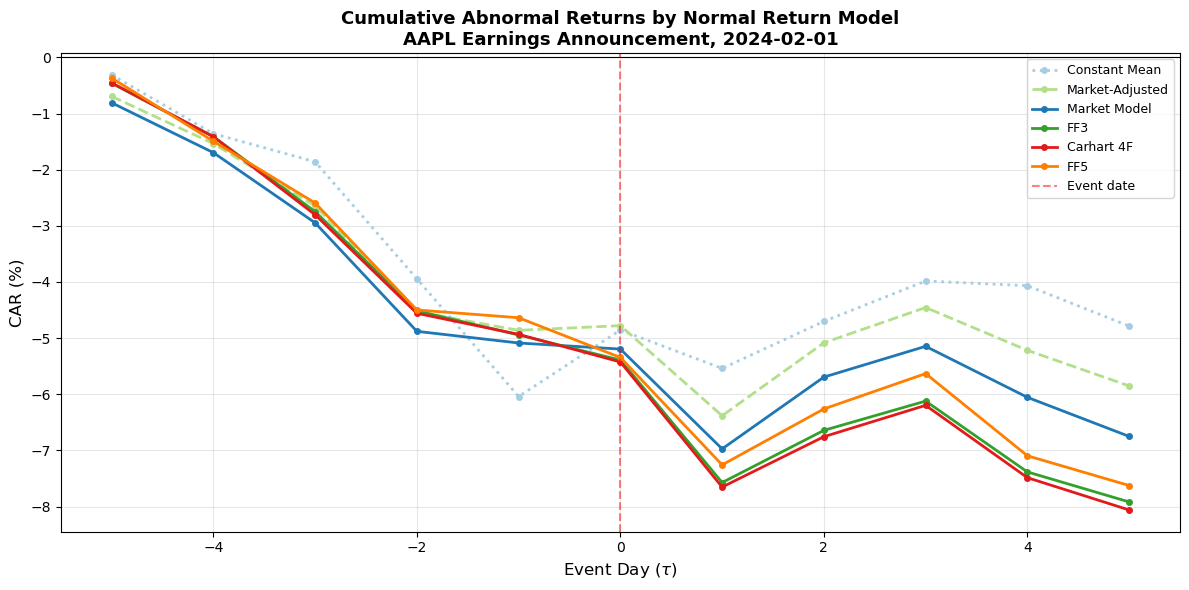

In [25]:
fig, ax = plt.subplots(figsize=(12, 6))

colors = {
    'Constant Mean': '#a6cee3',
    'Market-Adjusted': '#b2df8a',
    'Market Model': '#1f78b4',
    'FF3': '#33a02c',
    'Carhart 4F': '#e31a1c',
    'FF5': '#ff7f00',
}
linestyles = {
    'Constant Mean': ':',
    'Market-Adjusted': '--',
    'Market Model': '-',
    'FF3': '-',
    'Carhart 4F': '-',
    'FF5': '-',
}

for name in ['Constant Mean', 'Market-Adjusted', 'Market Model', 'FF3', 'Carhart 4F', 'FF5']:
    r = results[name]
    ax.plot(event_days, r['car'] * 100, label=name,
            color=colors[name], linestyle=linestyles[name], linewidth=2, marker='o', markersize=4)

ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='red', linewidth=1.5, linestyle='--', alpha=0.5, label='Event date')
ax.set_xlabel('Event Day ($\\tau$)', fontsize=12)
ax.set_ylabel('CAR (%)', fontsize=12)
ax.set_title(f'Cumulative Abnormal Returns by Normal Return Model\n{ticker} Earnings Announcement, {event_date.date()}',
             fontsize=13, fontweight='bold')
ax.legend(loc='best', frameon=True, fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 7.3 Daily Abnormal Returns Side by Side

To see where the models diverge on specific days, the following table and heatmap display the daily abnormal returns for each model. Large discrepancies on particular days indicate that the market-wide factor realizations on those days were unusual, making the benchmark adjustment matter more.

In [27]:
ar_df = pd.DataFrame(
    {name: results[name]['ar'] * 100 for name in
     ['Constant Mean', 'Market-Adjusted', 'Market Model', 'FF3', 'Carhart 4F', 'FF5']},
    index=event_days
)
ar_df.index.name = 'Event Day'

print("Daily Abnormal Returns (%) by Model")
print("=" * 80)
print(ar_df.round(4).to_string())

Daily Abnormal Returns (%) by Model
           Constant Mean  Market-Adjusted  Market Model     FF3  Carhart 4F     FF5
Event Day                                                                          
-5               -0.3112          -0.6945       -0.8077 -0.4594     -0.4533 -0.3676
-4               -1.0468          -0.8402       -0.8884 -0.9520     -0.9592 -1.1250
-3               -0.5007          -1.1121       -1.2504 -1.3355     -1.3901 -1.1005
-2               -2.0848          -1.8833       -1.9321 -1.7659     -1.7549 -1.9046
-1               -2.0962          -0.3311       -0.2077 -0.4310     -0.3747 -0.1391
 0                1.1838           0.0836       -0.1086 -0.4467     -0.4928 -0.7077
 1               -0.6834          -1.6047       -1.7772 -2.1812     -2.2274 -1.9131
 2                0.8384           1.2990        1.2787  0.9295      0.8973  0.9970
 3                0.7181           0.6287        0.5478  0.5213      0.5582  0.6294
 4               -0.0833          -0.762

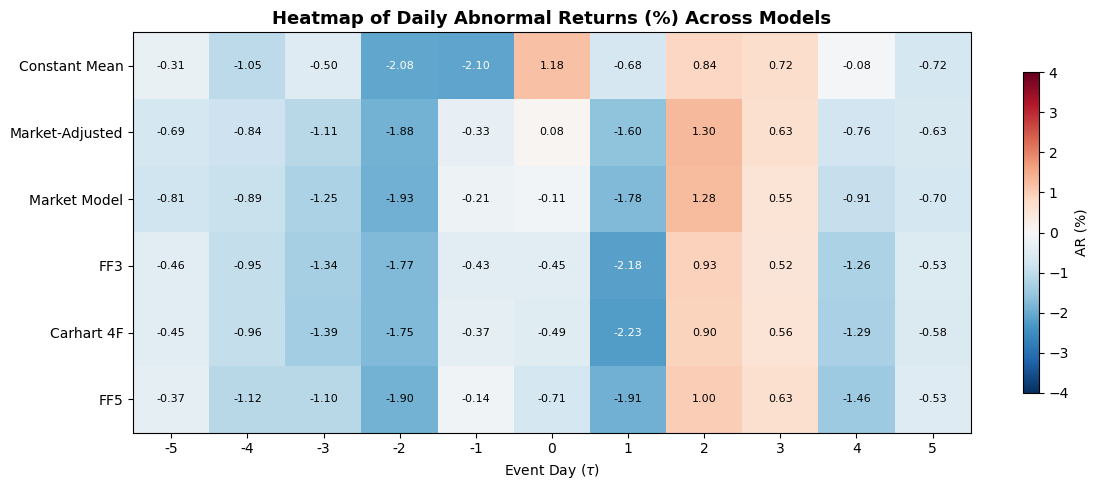

In [32]:
fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(ar_df.T.values, aspect='auto', cmap='RdBu_r', vmin=-4, vmax=4)

ax.set_xticks(range(len(event_days)))
ax.set_xticklabels(event_days)
ax.set_yticks(range(len(ar_df.columns)))
ax.set_yticklabels(ar_df.columns)
ax.set_xlabel('Event Day ($\\tau$)')
ax.set_title('Heatmap of Daily Abnormal Returns (%) Across Models', fontsize=13, fontweight='bold')

for i in range(len(ar_df.columns)):
    for j in range(len(event_days)):
        val = ar_df.T.values[i, j]
        color = 'white' if abs(val) > 2.0 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8, color=color)

plt.colorbar(im, ax=ax, label='AR (%)', shrink=0.8)
plt.tight_layout()
plt.show()

## 8. Estimation Window Design

The estimation window must be long enough to yield precise parameter estimates, but short enough to avoid structural breaks in the firm's factor exposures. There is no universally optimal length; the choice depends on the trade-off between estimation precision and parameter stability.

**Length.** MacKinlay (1997) recommends a minimum of 120 trading days. Most published studies use 200 to 250 trading days. Campbell, Lo, and MacKinlay (1997, p. 157) note that increasing the estimation window beyond 250 days yields diminishing precision gains.

**Pre-event versus rolling.** The standard approach uses a fixed pre-event window. An alternative is a rolling or expanding window that updates as new data arrives, but this complicates the event study design and is rarely used in practice.

**Exclusions.** If the firm experienced a major confounding event during the estimation window (a prior earnings announcement, a CEO change, a stock split), the researcher should either exclude those dates or extend the window to avoid them. The key is that the estimation window should represent "normal" market conditions for the firm.

We now examine how the choice of estimation window length affects the estimated parameters and the resulting CAR.

In [34]:
# Examine sensitivity to estimation window length
window_lengths = [60, 120, 180, 250, 350]
sensitivity = []

for L in window_lengths:
    est_end_idx = event_start - buffer - 1
    est_start_idx = est_end_idx - L + 1

    if est_start_idx < 0:
        continue

    est_slice = data.iloc[est_start_idx:est_end_idx + 1]
    y_e = est_slice['firm'].values
    X_e = sm.add_constant(est_slice['market'].values)

    model_fit = sm.OLS(y_e, X_e).fit()
    alpha, beta = model_fit.params
    sig = np.sqrt(model_fit.mse_resid)

    predicted = alpha + beta * evt_data['market'].values
    ar_temp = evt_data['firm'].values - predicted
    car_temp = np.cumsum(ar_temp)

    sensitivity.append({
        'L': L,
        'alpha': alpha,
        'beta': beta,
        'sigma_eps (%)': sig * 100,
        'R-sq': model_fit.rsquared,
        'CAR(-5,+5) (%)': car_temp[-1] * 100,
    })

sens_df = pd.DataFrame(sensitivity).set_index('L')
print("Sensitivity of Market Model to Estimation Window Length")
print("=" * 65)
print(sens_df.round(4).to_string())

Sensitivity of Market Model to Estimation Window Length
      alpha    beta  sigma_eps (%)    R-sq  CAR(-5,+5) (%)
L                                                         
60  -0.0011  1.0207         0.8245  0.4775         -4.7004
120 -0.0008  1.1120         0.9591  0.4322         -5.2720
180 -0.0002  1.1033         0.8860  0.4678         -5.9035
250  0.0006  1.1101         0.8886  0.5093         -6.7501


The table above shows that $\hat{\beta}$ and the resulting CAR are reasonably stable across estimation window lengths of 120 or more. Below 120 days, sampling variability in $\hat{\beta}$ starts to affect the CAR noticeably. This is consistent with MacKinlay's (1997) recommendation and provides empirical support for using at least 120 trading days.

## 9. Diagnostics: Parameter Stability and Residual Behavior

Before trusting the abnormal returns, we should verify that the estimated model provides a reasonable description of normal returns. Three diagnostic categories are standard.

### 9.1 Residual Autocorrelation

The market model assumes i.i.d. residuals. Serial correlation in the residuals indicates model misspecification (e.g., omitted factors or stale prices). The Durbin-Watson statistic tests for first-order autocorrelation; the Ljung-Box test generalizes this to higher orders.

In [36]:
from statsmodels.stats.diagnostic import acorr_ljungbox

mm_result = results['Market Model']['ols']
resid = mm_result.resid

dw = sm.stats.stattools.durbin_watson(resid)

lb = acorr_ljungbox(resid, lags=[1, 5, 10], return_df=True)

print("Residual Autocorrelation Diagnostics (Market Model)")
print("=" * 55)
print(f"  Durbin-Watson statistic: {dw:.4f}  (near 2 = no autocorrelation)\n")
print("  Ljung-Box test:")
print(lb.to_string())
print("\n  (p-values > 0.05 indicate no significant autocorrelation at that lag)")

Residual Autocorrelation Diagnostics (Market Model)
  Durbin-Watson statistic: 1.7210  (near 2 = no autocorrelation)

  Ljung-Box test:
     lb_stat  lb_pvalue
1   4.851589   0.027621
5   7.976569   0.157532
10  9.929365   0.446712

  (p-values > 0.05 indicate no significant autocorrelation at that lag)


### 9.2 Heteroskedasticity

If the residual variance is not constant over the estimation window, the OLS standard errors (and hence the abnormal return variance) are biased. The Breusch-Pagan test regresses the squared residuals on the regressors; a significant result indicates heteroskedasticity.

In [38]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_stat, bp_pval, bp_f, bp_f_pval = het_breuschpagan(resid, mm_result.model.exog)

print("Breusch-Pagan Heteroskedasticity Test (Market Model)")
print("=" * 55)
print(f"  LM statistic:  {bp_stat:.4f}")
print(f"  LM p-value:    {bp_pval:.4f}")
print(f"  F-statistic:   {bp_f:.4f}")
print(f"  F p-value:     {bp_f_pval:.4f}")
if bp_pval < 0.05:
    print("\n  Conclusion at 5%: Heteroskedasticity detected")
else:
    print("\n  Conclusion at 5%: No significant heteroskedasticity")

Breusch-Pagan Heteroskedasticity Test (Market Model)
  LM statistic:  0.4500
  LM p-value:    0.5023
  F-statistic:   0.4472
  F p-value:     0.5043

  Conclusion at 5%: No significant heteroskedasticity


### 9.3 Parameter Stability: The Chow Test

The Chow test checks whether the model parameters are stable over two sub-periods. We split the estimation window in half and test whether the coefficients differ significantly between the two halves. A rejection indicates that the firm's market beta shifted during the estimation window, which would bias the abnormal return estimates.

The test statistic is:

$$
F = \frac{(SSR_{\text{pooled}} - SSR_1 - SSR_2) / k}{(SSR_1 + SSR_2) / (L - 2k)}
$$

where $SSR_{\text{pooled}}$ is the sum of squared residuals from the full-sample regression, $SSR_1$ and $SSR_2$ are from the two sub-samples, $k$ is the number of parameters, and $L$ is the total number of observations.

In [40]:
from scipy import stats as sp_stats

def chow_test(y, X, split_idx):
    # Perform a Chow breakpoint test. Returns F-stat, p-value, (n1, n2, k).
    n = len(y)
    k = X.shape[1]

    ssr_pooled = sm.OLS(y, X).fit().ssr
    ssr1 = sm.OLS(y[:split_idx], X[:split_idx]).fit().ssr
    ssr2 = sm.OLS(y[split_idx:], X[split_idx:]).fit().ssr

    F_stat = ((ssr_pooled - ssr1 - ssr2) / k) / ((ssr1 + ssr2) / (n - 2 * k))
    p_val = 1 - sp_stats.f.cdf(F_stat, k, n - 2 * k)

    return F_stat, p_val, (split_idx, n - split_idx, k)

y_chow = est_data['firm'].values
X_chow = sm.add_constant(est_data['market'].values)
mid = len(y_chow) // 2

F_chow, p_chow, (n1, n2, k) = chow_test(y_chow, X_chow, mid)

print("Chow Breakpoint Test (Market Model, split at midpoint)")
print("=" * 55)
print(f"  Sub-sample 1: {n1} obs  |  Sub-sample 2: {n2} obs")
print(f"  F-statistic:  {F_chow:.4f}")
print(f"  p-value:      {p_chow:.4f}")
if p_chow < 0.05:
    print("\n  Conclusion at 5%: Parameter instability detected")
else:
    print("\n  Conclusion at 5%: No evidence of instability")

Chow Breakpoint Test (Market Model, split at midpoint)
  Sub-sample 1: 125 obs  |  Sub-sample 2: 125 obs
  F-statistic:  2.6237
  p-value:      0.0746

  Conclusion at 5%: No evidence of instability


### 9.4 Rolling Beta Estimate

A complementary visual diagnostic is to plot the estimated $\hat{\beta}_i$ over rolling sub-windows within the estimation period. If the beta is stable, the rolling estimates should fluctuate modestly around a constant value. Large swings indicate time-varying risk exposure, which may warrant a shorter estimation window or a different model specification.

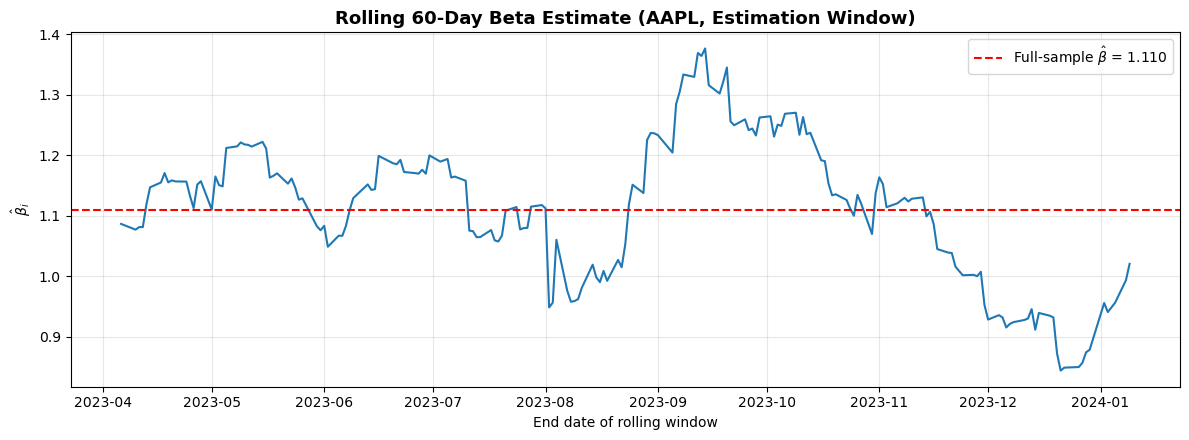

In [73]:
rolling_window = 60
n_obs = len(est_data)
roll_betas = []
roll_dates = []

for start_r in range(0, n_obs - rolling_window + 1):
    end_r = start_r + rolling_window
    y_r = est_data['firm'].values[start_r:end_r]
    X_r = sm.add_constant(est_data['market'].values[start_r:end_r])
    beta_r = sm.OLS(y_r, X_r).fit().params[1]
    roll_betas.append(beta_r)
    roll_dates.append(est_data.index[end_r - 1])

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(roll_dates, roll_betas, color='#1f78b4', linewidth=1.5)
ax.axhline(results['Market Model']['ols'].params[1], color='red', linestyle='--',
           linewidth=1.5, label=f'Full-sample $\\hat{{\\beta}}$ = {results["Market Model"]["ols"].params[1]:.3f}')
ax.set_xlabel('End date of rolling window')
ax.set_ylabel('$\\hat{\\beta}_i$')
ax.set_title(f'Rolling 60-Day Beta Estimate ({ticker}, Estimation Window)', fontsize=13, fontweight='bold')
ax.legend(frameon=True)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Thin Trading and Non-Synchronous Trading Corrections

For liquid large-cap stocks like Apple, thin trading is not a concern. But many event studies involve small-cap stocks, stocks in emerging markets, or bonds where trading is infrequent. Stocks that do not trade every day exhibit two pathological properties in daily return data: zero returns on non-trading days (which depresses volatility estimates) and spurious autocorrelation (because the "closing price" is stale).

The consequence for event studies is that the estimated $\hat{\beta}_i$ is biased toward zero. Two classical corrections exist.

**Scholes-Williams (1977)** estimate the beta using leads, lags, and the contemporaneous market return:

$$
\hat{\beta}^{SW}_i = \frac{\hat{\beta}^{-}_i + \hat{\beta}^{0}_i + \hat{\beta}^{+}_i}{1 + 2\hat{\rho}_m}
$$

where $\hat{\beta}^{-}_i$, $\hat{\beta}^{0}_i$, $\hat{\beta}^{+}_i$ are the slope coefficients from regressing $R_{i,t}$ on $R_{m,t-1}$, $R_{m,t}$, and $R_{m,t+1}$ separately, and $\hat{\rho}_m$ is the first-order autocorrelation of market returns.

**Dimson (1979)** includes leads and lags simultaneously in a single regression:

$$
R_{i,t} = \alpha_i + \beta^{-}_i R_{m,t-1} + \beta^{0}_i R_{m,t} + \beta^{+}_i R_{m,t+1} + \varepsilon_{i,t}
$$

The adjusted beta is $\hat{\beta}^{D}_i = \hat{\beta}^{-}_i + \hat{\beta}^{0}_i + \hat{\beta}^{+}_i$.

We implement both corrections below, though for Apple the difference will be negligible.

In [76]:
# Scholes-Williams beta
rm = est_data['market'].values
ri = est_data['firm'].values

# Lagged, contemporaneous, and lead regressions
beta_lag = sm.OLS(ri[1:], sm.add_constant(rm[:-1])).fit().params[1]
beta_contemp = sm.OLS(ri, sm.add_constant(rm)).fit().params[1]
beta_lead = sm.OLS(ri[:-1], sm.add_constant(rm[1:])).fit().params[1]

# First-order autocorrelation of market returns
rho_m = np.corrcoef(rm[:-1], rm[1:])[0, 1]

beta_sw = (beta_lag + beta_contemp + beta_lead) / (1 + 2 * rho_m)

# Dimson beta: include leads and lags simultaneously
ri_dim = ri[1:-1]
X_dimson = sm.add_constant(np.column_stack([rm[:-2], rm[1:-1], rm[2:]]))
dimson_fit = sm.OLS(ri_dim, X_dimson).fit()
beta_dimson = dimson_fit.params[1] + dimson_fit.params[2] + dimson_fit.params[3]

print("Thin Trading Corrections")
print("=" * 50)
print(f"  Standard OLS beta:      {beta_contemp:.4f}")
print(f"  Scholes-Williams beta:  {beta_sw:.4f}")
print(f"  Dimson beta:            {beta_dimson:.4f}")
print(f"\n  For a liquid stock like {ticker}, the corrections are minimal.")
print("  For thinly traded stocks, the difference can be substantial.")

Thin Trading Corrections
  Standard OLS beta:      1.1101
  Scholes-Williams beta:  1.0747
  Dimson beta:            1.0667

  For a liquid stock like AAPL, the corrections are minimal.
  For thinly traded stocks, the difference can be substantial.


## 11. When Does Model Choice Matter?

The empirical comparison in Section 7 shows the typical pattern documented by Brown and Warner (1980, 1985): for a large-cap stock with a narrow event window, the CARs from different models are broadly similar. The constant mean model gives the largest deviations because it fails to remove market-wide movements, but the market model, FF3, Carhart 4F, and FF5 produce CARs that are close to each other.

This convergence breaks down in several situations.

First, when the **event window is long** (months rather than days), cumulated benchmark errors compound and the choice of model has a large effect on the measured abnormal return. This is the "bad model problem" identified by Fama (1998), which we examine in Session 7.

Second, when **events cluster in calendar time**, all firms in the sample are exposed to the same factor realizations during the event window. A model that omits a relevant factor will systematically misestimate normal returns for the entire cross-section. The multi-factor models provide partial insurance against this problem.

Third, for **small-cap, high-beta, or value stocks** with large factor loadings, the additional factors in FF3 or FF5 absorb substantial return variation that the market model misses. In such samples, the multi-factor models genuinely improve the precision of abnormal return estimates.

The practical recommendation is to estimate at least the market model and one multi-factor model, and to report the sensitivity of results to the model choice. If the conclusions are qualitatively the same across models, the researcher can proceed with confidence. If they diverge, the choice of model requires careful justification.

## 12. Factor Loadings Across Models

To understand why the multi-factor models produce different abnormal returns, it is instructive to compare the estimated factor loadings. The table below reports the full regression output for the market model, FF3, Carhart 4F, and FF5. The key question is whether the additional factors have statistically significant loadings. If they do, the multi-factor model is absorbing return variation that the market model attributes to the abnormal return.

In [78]:
model_names_ols = ['Market Model', 'FF3', 'Carhart 4F', 'FF5']
factor_labels = {
    'Market Model': ['const', 'R_m'],
    'FF3': ['const', 'MKT-RF', 'SMB', 'HML'],
    'Carhart 4F': ['const', 'MKT-RF', 'SMB', 'HML', 'MOM'],
    'FF5': ['const', 'MKT-RF', 'SMB', 'HML', 'RMW', 'CMA'],
}

print("Factor Loadings and t-statistics")
print("=" * 80)
for name in model_names_ols:
    r = results[name]
    ols = r['ols']
    labels = factor_labels[name]
    print(f"\n  {name}  (R-sq = {ols.rsquared:.4f}, Adj. R-sq = {ols.rsquared_adj:.4f})")
    print(f"  {'Factor':<10} {'Coef':>10} {'Std Err':>10} {'t-stat':>10} {'p-val':>10}")
    print(f"  {'-'*50}")
    for i, lab in enumerate(labels):
        print(f"  {lab:<10} {ols.params[i]:>10.5f} {ols.bse[i]:>10.5f} "
              f"{ols.tvalues[i]:>10.3f} {ols.pvalues[i]:>10.4f}")

Factor Loadings and t-statistics

  Market Model  (R-sq = 0.5093, Adj. R-sq = 0.5073)
  Factor           Coef    Std Err     t-stat      p-val
  --------------------------------------------------
  const         0.00055    0.00056      0.982     0.3270
  R_m           1.11014    0.06919     16.045     0.0000

  FF3  (R-sq = 0.5692, Adj. R-sq = 0.5639)
  Factor           Coef    Std Err     t-stat      p-val
  --------------------------------------------------
  const         0.00025    0.00053      0.477     0.6337
  MKT-RF        1.07463    0.06665     16.124     0.0000
  SMB          -0.22010    0.08506     -2.588     0.0102
  HML          -0.36156    0.07704     -4.693     0.0000

  Carhart 4F  (R-sq = 0.5700, Adj. R-sq = 0.5630)
  Factor           Coef    Std Err     t-stat      p-val
  --------------------------------------------------
  const         0.00027    0.00053      0.507     0.6129
  MKT-RF        1.08449    0.06820     15.902     0.0000
  SMB          -0.19222    0.0940

## 13. Summary and Preview of Session 3

This session covered the hierarchy of normal return models used in event studies: the constant mean model, the market-adjusted model, the market model, and the Fama-French three-factor, Carhart four-factor, and Fama-French five-factor models. We estimated all six on the same dataset and found that, for a large-cap stock with a short event window, the resulting CARs are similar across specifications.

We then examined the design choices that affect estimation quality: window length, buffer period, and treatment of confounding events. Diagnostic tests for residual autocorrelation (Durbin-Watson, Ljung-Box), heteroskedasticity (Breusch-Pagan), and parameter stability (Chow test, CUSUM, rolling beta) provide formal tools for validating the model before interpreting the abnormal returns. Finally, we introduced the Scholes-Williams and Dimson corrections for thin trading bias.

Session 3 turns to the aggregation and presentation of results: building from single-firm ARs to cross-sectional CAARs, handling missing data and weighting schemes, and establishing the graphical conventions for reporting event study results. We will also begin constructing a reusable Python toolkit that carries forward into all subsequent sessions.

**Additional references:**

- Fama, E.F. (1998). Market Efficiency, Long-Term Returns, and Behavioral Finance. *Journal of Financial Economics*, 49(3), 283--306.
- Harvey, A.C. (1990). *The Econometric Analysis of Time Series*. MIT Press. 2nd edition.